In [10]:
import qiskit as qk
from qiskit import QuantumCircuit
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import BasisTranslator
from qiskit.compiler import transpile
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
import numpy as np
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit.quantum_info import Operator

from tqdm import tqdm
import json

In [11]:
from pmns import PMNS_matrix_4x4
from hamiltonians import U1_omega_Omega, theta_ij, J_ij
from hamiltonians import nunu_interaction_p, nunu_interaction, nunu_interaction_s
from helpers import get_target_state, swap_correction_order_bp, get_interaction_pair_index

from backend import get_sampler
from transpile import produce_transpile_args

import sys

sys.path.append('../utils/')

from JobResult import JobResult

from Collector import Collector

from CircuitConvert import qiskit_to_quimb

In [12]:
# backend settings
tensor_config = json.load(open("config/tensor_config.json"))

run_name = "32nu"

# sampler, backend, config = get_sampler('aer')
config = None
N = 8

# trotter settings
# set in natural units here
# conversion to mu^-1 happens later automatically
steps = 5
T_max = 20

# run settings

shots = 8192

# print(produce_transpile_args(tensor_config, transpile_config_path))

In [13]:
#### Defining PMNS matrix and parameters for the Hamiltonian ####
theta_12 = np.radians(33.67)
theta_13 = np.radians(8.58)
theta_23 = np.radians(42.3)
delta_CP = np.radians(232)

U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
assert np.allclose(U_PMNS_4x4.conj().T @ U_PMNS_4x4, np.eye(4)), "PMNS matrix is not unitary"

dm21 = 7.41e-5
dm31 = 2.505e-3
E = 1.0

delta_m21 = dm21
delta_m31 = dm31
delta_m32 = delta_m31 - delta_m21
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)
#omega = np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3) / (4 * E)
omega=dm21 / (2 * E)  
Omega= dm31 / (2 * E)
#B3 = delta_m21 / np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3)
#B8 = (delta_m31 + delta_m32) / (np.sqrt(3) * np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3))
B3=0.025483
B8=0.999567
B = np.zeros(8)
B[2] = B3
B[7] = B8

# dt = dt / mu
T_max = T_max / mu

# dt = T_max / steps
# steps = int(T_max / dt) + 1
times = np.linspace(0, T_max, steps)

In [14]:
def apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt, interact_func = nunu_interaction, post_fix_func = None):
    """
    interact_func: function for the interaction, for example, nunu_interaction or nunu_interaction_p
    post_fix_func: function to update the order and base_pattern after interaction, given by (order, base_pattern, i, j) -> (new_order, new_base_pattern)
    """
    for i, j in pair_indices:
        q = [2*i, 2*i+1, 2*j, 2*j+1]
        alpha_ij = J_ij(order[i], order[j], E, mu, N) * dt

        interact_func(qc, q, alpha_ij)
        order, base_pattern = post_fix_func(order, base_pattern, i, j) if post_fix_func else (order, base_pattern)
        
    return order, base_pattern


In [15]:
# initialization for run


def init_order_and_base_pattern():
    # generate initial pattern
    base_pattern = []
    for i in range(N):
        if i % 4 == 1:
            base_pattern.append('M')  # nu_mu
        elif i % 4 == 3:
            base_pattern.append('T')  # nu_tau
        else:
            base_pattern.append('E')  # nu_e

    # order map
    order = [i for i in range(N)]

    return order, base_pattern

# interaction sequence
pair_indices = get_interaction_pair_index(N, method = 'default')

# collect data

collector = Collector(run_name)

In [16]:
for t in times:
    dt = t
    collector.add('t', t * mu)

    order, base_pattern = init_order_and_base_pattern()
    qc = QuantumCircuit(2 * N, 2 * N)

    # Initial state: alternate nu_e, nu_mu, nu_e, nu_tau pattern
    for i in range(N):
        if i % 4 == 1:
            qc.x(2*i + 1)  # nu_mu = |01⟩
        elif i % 4 == 3:
            qc.x(2*i)      # nu_tau = |10⟩

    # Apply U†_PMNS
    Udag = Operator(U_PMNS_4x4.conj().T)
    for i in range(N):
        qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS")

    # Trotterization
    for i in range(N):
        qc.append(U1_omega_Omega(dt, omega, Omega), [2*i, 2*i+1])

    # order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt,
    #                                              interact_func=nunu_interaction_p,
    #                                              post_fix_func=swap_correction_order_bp)
    order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt,
                                                    interact_func=nunu_interaction,
                                                    post_fix_func=None)

    # Apply U_PMNS
    U = Operator(U_PMNS_4x4)
    for i in range(N):
        qc.unitary(U, [2*i, 2*i+1], label="U_PMNS")

    # Measurement
    # qc.measure(range(2 * N), reversed((range(2 * N))))

    # transpile_args = {"optimization_level": 3, "basis_gates": ['x', 'sx', 'cz', 'rz']}

    # # @HACK hacking the option to always have enough qubits
    # transpile_args['coupling_map'] = qk.transpiler.CouplingMap.from_full(4*N)

    tqc = transpile(qc, basis_gates=['x', 'sx', 'cz', 'rz'])

    tqc = qiskit_to_quimb(tqc, backend='torch')

    counts = {}

    print("Beginning sampling...")

    # for s in tqdm(tqc.sample(shots, seed = 42, backend='torch'), total=shots):
    #     if s in counts:
    #         counts[s] += 1
    #     else:
    #         counts[s] = 1

    for s in tqdm(tqc.sample_gate_by_gate(shots, seed = 42), total=shots):
        if s in counts:
            counts[s] += 1
        else:
            counts[s] = 1

    target_state = get_target_state(base_pattern)

    prob = counts.get(target_state, 0) / shots
    # print("Measurement counts:", counts)
    # probabilities.append(prob)
    collector.add("p", prob)

collector.save(path = 'results')


Beginning sampling...


100%|██████████| 8192/8192 [00:00<00:00, 32540.59it/s]


Beginning sampling...


  0%|          | 0/8192 [00:00<?, ?it/s]/Users/erma/Documents/QNova/venv/lib/python3.12/site-packages/autoray/autoray.py:81: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/erma/Documents/QNova/venv/lib/python3.12/site-packages/autoray/autoray.py:81: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/erma/Documents/QNova/venv/lib/python3.12/site-packages/autoray/autoray.py:81: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)
100%|██████████| 8192/8192 [00:05<00:00, 1398.22it/s]


Beginning sampling...


...

Beginning sampling...


  0%|          | 0/8192 [00:00<?, ?it/s]/Users/erma/Documents/QNova/venv/lib/python3.12/site-packages/autoray/autoray.py:81: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/erma/Documents/QNova/venv/lib/python3.12/site-packages/autoray/autoray.py:81: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/erma/Documents/QNova/venv/lib/python3.12/site-packages/autoray/autoray.py:81: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)
100%|██████████| 8192/8192 [00:04<00:00, 1691.91it/s]


Beginning sampling...


  0%|          | 0/8192 [00:00<?, ?it/s]/Users/erma/Documents/QNova/venv/lib/python3.12/site-packages/autoray/autoray.py:81: RuntimeWarning: divide by zero encountered in matmul
  return func(*args, **kwargs)
/Users/erma/Documents/QNova/venv/lib/python3.12/site-packages/autoray/autoray.py:81: RuntimeWarning: overflow encountered in matmul
  return func(*args, **kwargs)
/Users/erma/Documents/QNova/venv/lib/python3.12/site-packages/autoray/autoray.py:81: RuntimeWarning: invalid value encountered in matmul
  return func(*args, **kwargs)
100%|██████████| 8192/8192 [00:04<00:00, 1653.70it/s]

Saved 5 values for t to 32nu_t.npy
Saved 5 values for p to 32nu_p.npy


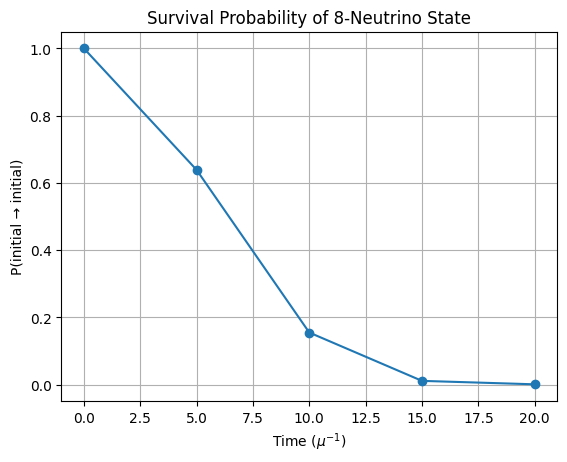

In [17]:
# Plot
plt.plot(collector.get('t'), collector.get('p'), marker='o')
plt.xlabel(r"Time ($\mu^{-1}$)")
plt.ylabel("P(initial → initial)")
plt.title("Survival Probability of {0}-Neutrino State".format(N))
plt.grid(True)
# plt.savefig("survi_prob_{0}_nu.png".format(N))